<h1>Импорт библиотек

In [3]:
import numpy as np
import matplotlib.pyplot as plt

<h1>Задача 1. Дан набор из $p$ матриц размерностью $(n, n)$ и $p$ векторов размерностью $(n, 1)$, найти сумму произведений матриц на векторы. Написать тесты для кода

In [6]:
def sum_prod(X, V):
    '''
    X - матрицы (n, n)
    V - векторы (n, 1)
    Гарантируется, что len(X) == len(V)
    '''

    res = 0
    for i in range(len(X)):
        res += X[i].dot(V[i])
    return res

A = np.array([[1, 2, 3],[4, 5, 6],[7, 8, 9]])
B = np.array([[9, 8, 7],[6, 5, 4],[3, 2, 1]])
a = np.array([1, 0, 1])  
b = np.array([2, 1, 3])  

print(sum_prod([A,B],[a,b])) # 51 39 27

[51 39 27]


<h1>Задача 2. Дана матрица M, напишите функцию, которая бинаризует матрицу по некоторому threshold (то есть, все значения большие threshold становятся равными 1, иначе 0). Напишите тесты для кода

In [9]:
def binarize(M, threshold=0.5):
    thresh = lambda x: 1 if x > threshold else 0
    return np.vectorize(thresh)(M)

m = np.array([[1, 2, 3],[4, 5, 6],[7, 8, 9]])
print(binarize(m, 5)) # [0 0 0] [0 0 1] [1 1 1]

[[0 0 0]
 [0 0 1]
 [1 1 1]]


<h1>Задача 3. Напишите функцию, которая возвращает уникальные элементы из каждой строки матрицы. Напишите такую же функцию, но для столбцов. Напишите тесты для кода

In [18]:
def unique_rows(mat):
    return [np.unique(x) for _, x in enumerate(mat)]

def unique_columns(mat):
    return [np.unique(x) for _, x in enumerate(mat.T)]

r = np.array([[2, 2, 2],[4, 4, 4],[8, 8, 8]]) # 2 4 8
c = np.array([[2, 4, 8],[2, 4, 8],[2, 4, 8]]) # 2 4 8
print(unique_rows(r))
print(unique_columns(c))

[array([2]), array([4]), array([8])]
[array([2]), array([4]), array([8])]


<h1>Задача 4. Напишите функцию, которая заполняет матрицу с размерами $(m, n)$ случайными числами, распределенными по нормальному закону. Затем считает мат. ожидание и дисперсию для каждого из столбцов и строк, а также строит для каждой строки и столбца гистограмму значений (использовать функцию hist из модуля matplotlib.plot)

Матрица 3x4 со случайным нормальным распределением:
[[-1.71313453  1.35387237 -0.11453985  1.23781631]
 [-1.59442766 -0.59937502  0.0052437   0.04698059]
 [-0.45006547  0.62284993 -1.06762043 -0.14237949]]


Математическое ожидание по строкам: [ 0.19100358 -0.5353946  -0.25930386]
Дисперсия по строкам: [1.54179486 0.43927379 0.37040807]

Математическое ожидание по столбцам: [-1.25254255  0.45911576 -0.39230552  0.38080581]
Дисперсия по столбцам: [0.32433329 0.64926701 0.23041646 0.37320971]


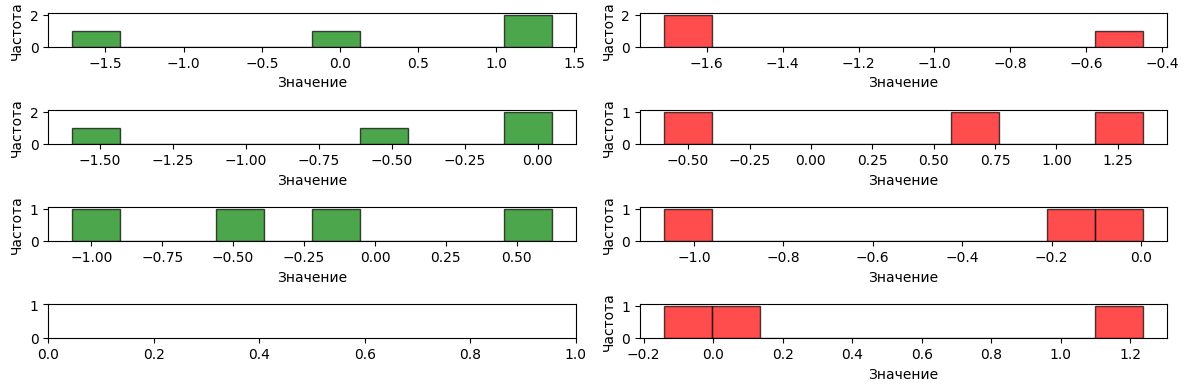

In [55]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_normal_matrix(m, n):
    matrix = np.random.normal(size=(m, n))
    print(f"Матрица {m}x{n} со случайным нормальным распределением:")
    print(matrix)
    print("\n" + "="*50 + "\n")

    # Считаем математическое ожидание и дисперсию
    row_means = np.mean(matrix, axis=1)
    row_vars = np.var(matrix, axis=1)
    col_means = np.mean(matrix, axis=0)
    col_vars = np.var(matrix, axis=0)
    print("Математическое ожидание по строкам:", row_means)
    print("Дисперсия по строкам:", row_vars)
    print("\nМатематическое ожидание по столбцам:", col_means)
    print("Дисперсия по столбцам:", col_vars)

    # Строим гистограммы
    fig, axes = plt.subplots(max(m,n), 2, figsize=(12, 4))

    # Гистограммы для строк
    for i in range(m):
        axes[i, 0].hist(matrix[i, :], bins=10, alpha=0.7, color='green', edgecolor='black')
        axes[i, 0].set_xlabel('Значение')
        axes[i, 0].set_ylabel('Частота')

    # Гистограммы для столбцов
    for j in range(n):
        axes[j, 1].hist(matrix[:, j], bins=10, alpha=0.7, color='red', edgecolor='black')
        axes[j, 1].set_xlabel('Значение')
        axes[j, 1].set_ylabel('Частота')

    plt.tight_layout()
    plt.show()


analyze_normal_matrix(3, 4)



<h1>Задача 5. Напишите функцию, которая заполняет матрицу $(m, n)$ в шахматном порядке заданными числами $a$ и $b$. Напишите тесты для кода

In [57]:
def chess_matrix(m, n, a, b):
    return np.array([[a if (i + j) % 2 == 0 else b for j in range(n)] for i in range(m)])

print(chess_matrix(5,3,1,2))

[[1 2 1]
 [2 1 2]
 [1 2 1]
 [2 1 2]
 [1 2 1]]


<h1>Задача 6. Напишите функцию, которая отрисовывает прямоугольник с заданными размерами (a, b) на изображении размера (m, n), цвет фона задайте в схеме RGB, как и цвет прямоугольника. Цвета также должны быть параметрами функции. Напишите аналогичную функцию но для овала с полуосями a и b. Напишите тесты для кода.
Примечание: уравнение эллипса (границы овала) можно записать как:
<h1>$\frac{(x-x_0)^2}{a^2}+\frac{(y-y_0)^2}{b^2}=1$

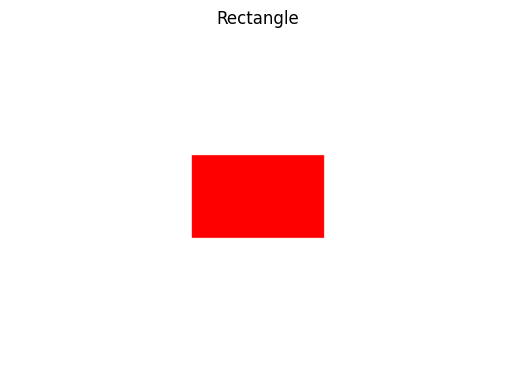

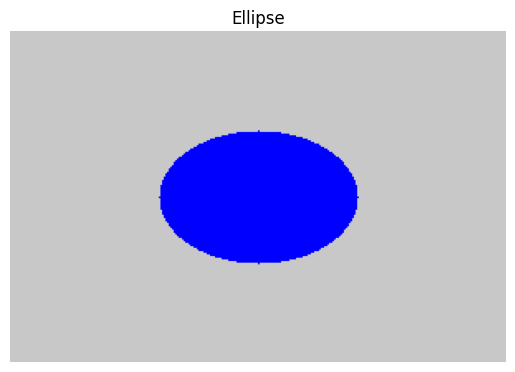

In [70]:
def draw_rectangle(a, b, m, n, rectangle_color, background_color):
    img = np.full((m, n, 3), background_color, dtype=np.uint8)
    start_row = (m - a) // 2  
    start_col = (n - b) // 2 
    img[start_row:start_row + a, start_col:start_col + b] = rectangle_color
    plt.imshow(img)
    plt.title("Rectangle")
    plt.axis('off')
    plt.show()

def draw_ellipse(a, b, m, n, ellipse_color, background_color):
    img = np.full((m, n, 3), background_color, dtype=np.uint8)
    y, x = np.ogrid[:m, :n]
    x0, y0 = n // 2, m // 2
    mask = ((x - x0)**2 / a**2 + (y - y0)**2 / b**2) <= 1
    img[mask] = ellipse_color
    plt.imshow(img)
    plt.title("Ellipse")
    plt.axis('off')
    plt.show()

# Тесты
draw_rectangle(50, 80, 200, 300, [255, 0, 0], [255, 255, 255])
draw_ellipse(60, 40, 200, 300, [0, 0, 255], [200, 200, 200])


<h1>Задача 7. Дан некий временной ряд. Для данного ряда нужно найти его: математическое ожидание, дисперсию, СКО, найти все локальные максимумы и минимумы (локальный максимум - это точка, которая больше своих соседних точек, а локальный минимум - это точка, которая меньше своих соседей), а также вычислить для данного ряда другой ряд, получаемый методом скользящего среднего с размером окна $p$.
<h1>Примечание: метод скользящего среднего подразумевает нахождение среднего из подмножетсва ряда размером $p$

In [72]:
def analyze_time_series(series, p):
    series = np.array(series)
    n = len(series)

    mean = np.mean(series)
    variance = np.var(series)
    std = np.std(series)

    local_maxima = []
    local_minima = []

    for i in range(1, n - 1):
        if series[i] > series[i - 1] and series[i] > series[i + 1]:
            local_maxima.append((i, series[i]))
        elif series[i] < series[i - 1] and series[i] < series[i + 1]:
            local_minima.append((i, series[i]))

    moving_avg = np.convolve(series, np.ones(p) / p, mode='valid')

    return {
        'mean': mean,
        'variance': variance,
        'std': std,
        'local_maxima': local_maxima,
        'local_minima': local_minima,
        'moving_average': moving_avg
    }

test_series = [1, 3, 2, 5, 4, 8, 6, 9, 7]
window_size = 3
results = analyze_time_series(test_series, window_size)

print(f"Исходный ряд: {test_series}")
print(f"Размер окна скользящего среднего: {window_size}")
print(f"Математическое ожидание: {results['mean']:.4f}")
print(f"Дисперсия: {results['variance']:.4f}")
print(f"СКО: {results['std']:.4f}")
print("Локальные максимумы (индекс, значение):", results['local_maxima'])
print("Локальные минимумы (индекс, значение):", results['local_minima'])
print(f"Скользящее среднее: {results['moving_average']}")


Исходный ряд: [1, 3, 2, 5, 4, 8, 6, 9, 7]
Размер окна скользящего среднего: 3
Математическое ожидание: 5.0000
Дисперсия: 6.6667
СКО: 2.5820
Локальные максимумы (индекс, значение): [(1, np.int64(3)), (3, np.int64(5)), (5, np.int64(8)), (7, np.int64(9))]
Локальные минимумы (индекс, значение): [(2, np.int64(2)), (4, np.int64(4)), (6, np.int64(6))]
Скользящее среднее: [2.         3.33333333 3.66666667 5.66666667 6.         7.66666667
 7.33333333]


<h1> Задача 8. Дан некоторый вектор с целочисленными метками классов, напишите функцию, которая выполняет one-hot-encoding для данного вектора
<h1> One-hot-encoding - представление, в котором на месте метки некоторого класса стоит 1, в остальных позициях стоит 0. Например для вектора [0, 2, 3, 0] one-hot-encoding выглядит как: [[1, 0, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1], [1, 0, 0, 0]]

In [75]:
def one_hot_encode(labels):
    labels = np.array(labels)
    num_classes = np.max(labels) + 1
    one_hot = np.zeros((len(labels), num_classes), dtype=int)
    one_hot[np.arange(len(labels)), labels] = 1
    return one_hot

print(one_hot_encode([0, 2, 3, 0]))


[[1 0 0 0]
 [0 0 1 0]
 [0 0 0 1]
 [1 0 0 0]]
